# LendingClub Credit Risk — Exploratory Data Analysis

Dataset: `wordsforthewise/lending-club` (accepted loans, 2007–2018Q4) via `kagglehub`.

This notebook explores loan volume, default rates by key risk segments, and the
relationship between borrower/loan characteristics and default risk, as a
foundation for credit risk strategy work.

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

path = kagglehub.dataset_download("wordsforthewise/lending-club")
print("Dataset path:", path)

Matplotlib is building the font cache; this may take a moment.


Dataset path: /Users/andreastio/.cache/kagglehub/datasets/wordsforthewise/lending-club/versions/3


## 1. Load data

The full accepted-loans file has ~2.26M rows and 151 columns. We load a curated subset of columns relevant to credit risk to keep memory manageable.

In [2]:
usecols = [
    "loan_amnt", "term", "int_rate", "installment", "grade", "sub_grade",
    "emp_length", "home_ownership", "annual_inc", "verification_status",
    "issue_d", "loan_status", "purpose", "dti", "delinq_2yrs",
    "fico_range_low", "fico_range_high", "inq_last_6mths", "open_acc",
    "pub_rec", "revol_bal", "revol_util", "total_acc", "application_type",
    "mort_acc", "pub_rec_bankruptcies", "addr_state",
]

csv_path = f"{path}/accepted_2007_to_2018Q4.csv.gz"

df = pd.read_csv(
    csv_path,
    usecols=usecols,
    low_memory=False,
)

print(df.shape)
df.head()

(2260701, 27)


,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,fico_range_low,fico_range_high,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,application_type,mort_acc,pub_rec_bankruptcies
0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,debt_consolidation,PA,5.91,0.0,675.0,679.0,1.0,7.0,0.0,2765.0,29.7,13.0,Individual,1.0,0.0
1,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,small_business,SD,16.06,1.0,715.0,719.0,4.0,22.0,0.0,21470.0,19.2,38.0,Individual,4.0,0.0
2,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,Not Verified,Dec-2015,Fully Paid,home_improvement,IL,10.78,0.0,695.0,699.0,0.0,6.0,0.0,7869.0,56.2,18.0,Joint App,5.0,0.0
3,35000.0,60 months,14.85,829.90,C,C5,10+ years,MORTGAGE,110000.0,Source Verified,Dec-2015,Current,debt_consolidation,NJ,17.06,0.0,785.0,789.0,0.0,13.0,0.0,7802.0,11.6,17.0,Individual,1.0,0.0
4,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,Source Verified,Dec-2015,Fully Paid,major_purchase,PA,25.37,1.0,695.0,699.0,3.0,12.0,0.0,21929.0,64.5,35.0,Individual,6.0,0.0


In [3]:
df.dtypes

loan_amnt               float64
term                        str
int_rate                float64
installment             float64
grade                       str
sub_grade                   str
emp_length                  str
home_ownership              str
annual_inc              float64
verification_status         str
issue_d                     str
loan_status                 str
purpose                     str
addr_state                  str
dti                     float64
delinq_2yrs             float64
fico_range_low          float64
fico_range_high         float64
inq_last_6mths          float64
open_acc                float64
pub_rec                 float64
revol_bal               float64
revol_util              float64
total_acc               float64
application_type            str
mort_acc                float64
pub_rec_bankruptcies    float64
dtype: object

## 2. Clean & derive fields

- Parse `term` and `revol_util` to numeric
- Parse `issue_d` to a datetime
- Build a FICO midpoint
- Define a binary default flag on *resolved* loans only (Fully Paid vs. Charged Off / Default); loans still `Current`, in a grace period, or late are excluded from default-rate calculations since their outcome isn't known yet.

In [4]:
df["term_months"] = df["term"].str.extract(r"(\d+)").astype(float)
df["revol_util"] = df["revol_util"].astype(str).str.rstrip("%").replace("nan", np.nan).astype(float)
df["issue_d"] = pd.to_datetime(df["issue_d"], format="%b-%Y")
df["fico_mid"] = (df["fico_range_low"] + df["fico_range_high"]) / 2

df["loan_status"].value_counts()

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

In [5]:
bad_statuses = ["Charged Off", "Default"]
good_statuses = ["Fully Paid"]
resolved = df[df["loan_status"].isin(bad_statuses + good_statuses)].copy()
resolved["is_default"] = resolved["loan_status"].isin(bad_statuses).astype(int)

print(f"Resolved loans: {len(resolved):,} of {len(df):,} total")
print(f"Overall default rate: {resolved['is_default'].mean():.2%}")

Resolved loans: 1,345,350 of 2,260,701 total
Overall default rate: 19.96%


## 3. Loan volume over time

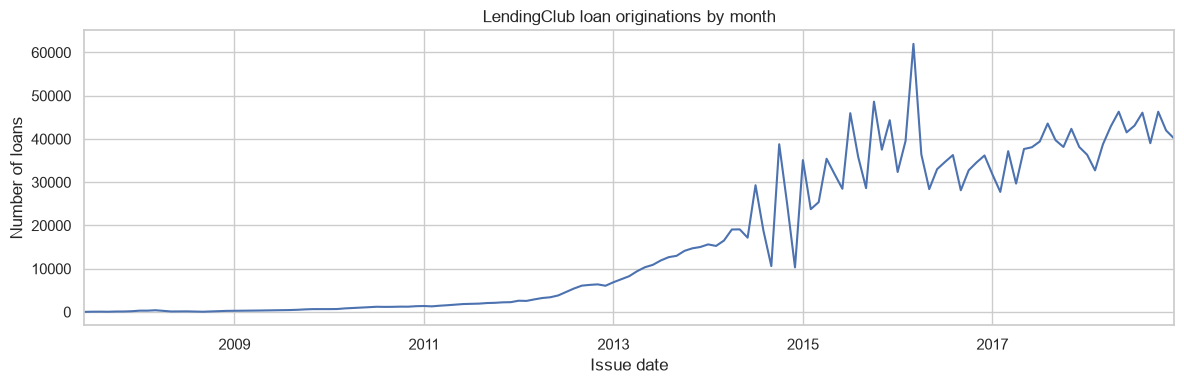

In [6]:
monthly = df.groupby(df["issue_d"].dt.to_period("M")).size()

fig, ax = plt.subplots(figsize=(12, 4))
monthly.plot(ax=ax)
ax.set_title("LendingClub loan originations by month")
ax.set_xlabel("Issue date")
ax.set_ylabel("Number of loans")
plt.tight_layout()
plt.show()

## 4. Default rate by grade & sub-grade

Grade is LendingClub's own risk rating, so this is a sanity check that observed defaults line up with it.

In [7]:
grade_default = resolved.groupby("grade")["is_default"].agg(["mean", "count"]).sort_index()
grade_default.columns = ["default_rate", "n_loans"]
grade_default

,default_rate,n_loans
grade,,
A,0.060427,235095
B,0.133867,392748
C,0.224413,381694
D,0.303867,200966
E,0.384823,93656
F,0.452042,32059
G,0.499343,9132


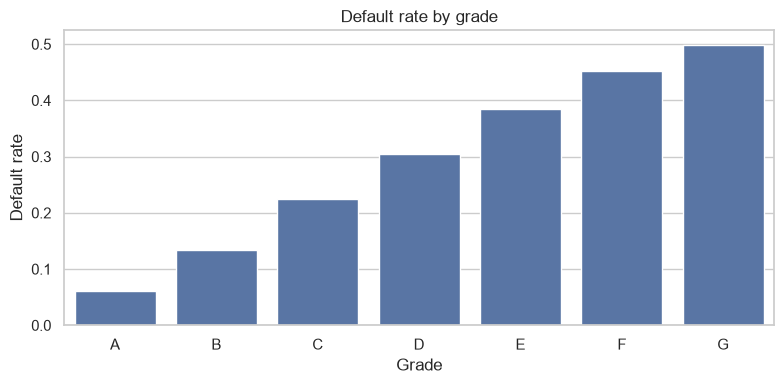

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=grade_default.index, y=grade_default["default_rate"], color="#4C72B0", ax=ax)
ax.set_title("Default rate by grade")
ax.set_ylabel("Default rate")
ax.set_xlabel("Grade")
plt.tight_layout()
plt.show()

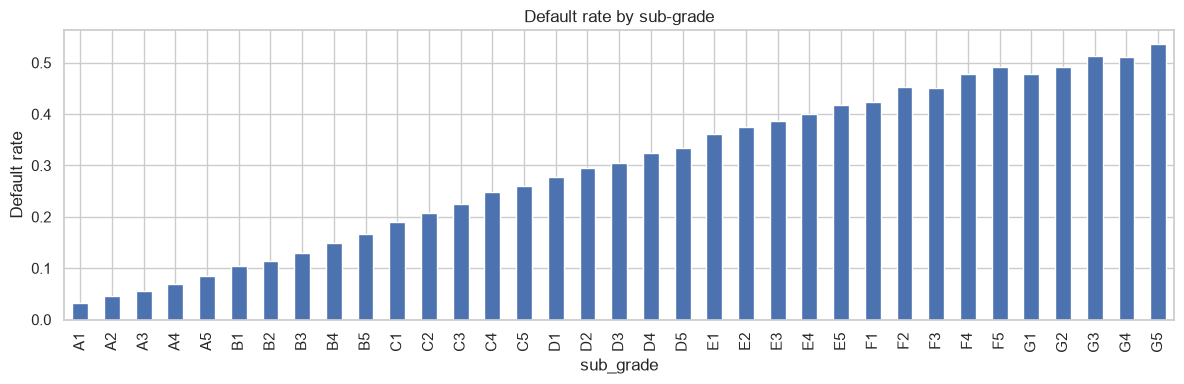

In [9]:
subgrade_default = resolved.groupby("sub_grade")["is_default"].mean().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
subgrade_default.plot(kind="bar", color="#4C72B0", ax=ax)
ax.set_title("Default rate by sub-grade")
ax.set_ylabel("Default rate")
plt.tight_layout()
plt.show()

## 5. Default rate by term and purpose

In [10]:
term_default = resolved.groupby("term_months")["is_default"].agg(["mean", "count"])
term_default.columns = ["default_rate", "n_loans"]
term_default

,default_rate,n_loans
term_months,,
36.0,0.159955,1020768
60.0,0.324485,324582


In [11]:
purpose_default = (
    resolved.groupby("purpose")["is_default"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "default_rate", "count": "n_loans"})
    .query("n_loans > 1000")
    .sort_values("default_rate", ascending=False)
)
purpose_default

,default_rate,n_loans
purpose,,
small_business,0.297094,15416
moving,0.233544,9480
house,0.218914,7254
medical,0.217858,15556
debt_consolidation,0.211491,780342
other,0.210422,77877
vacation,0.191726,9065
major_purchase,0.186054,29427
home_improvement,0.177186,87507


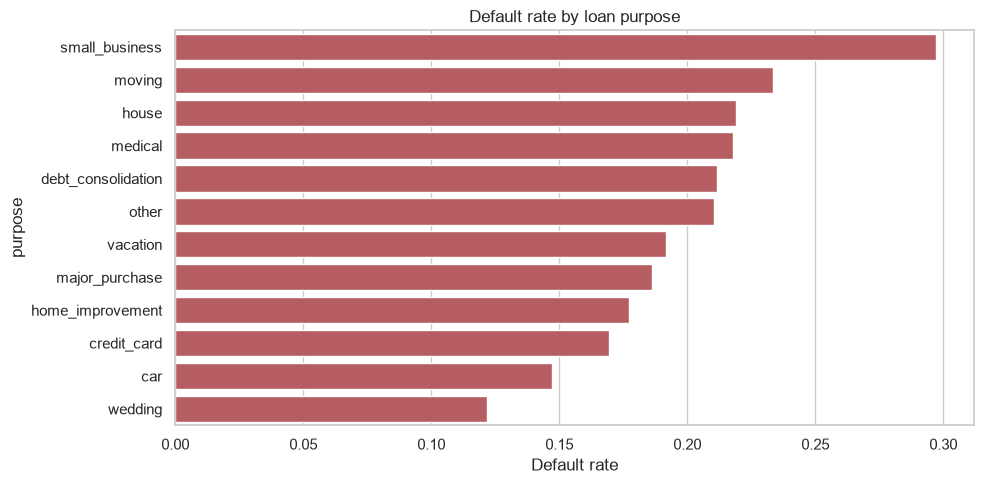

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(y=purpose_default.index, x=purpose_default["default_rate"], color="#C44E52", ax=ax)
ax.set_title("Default rate by loan purpose")
ax.set_xlabel("Default rate")
plt.tight_layout()
plt.show()

## 6. Key risk drivers: DTI, FICO, interest rate, income

Distributions compared between fully-paid and charged-off/defaulted loans.

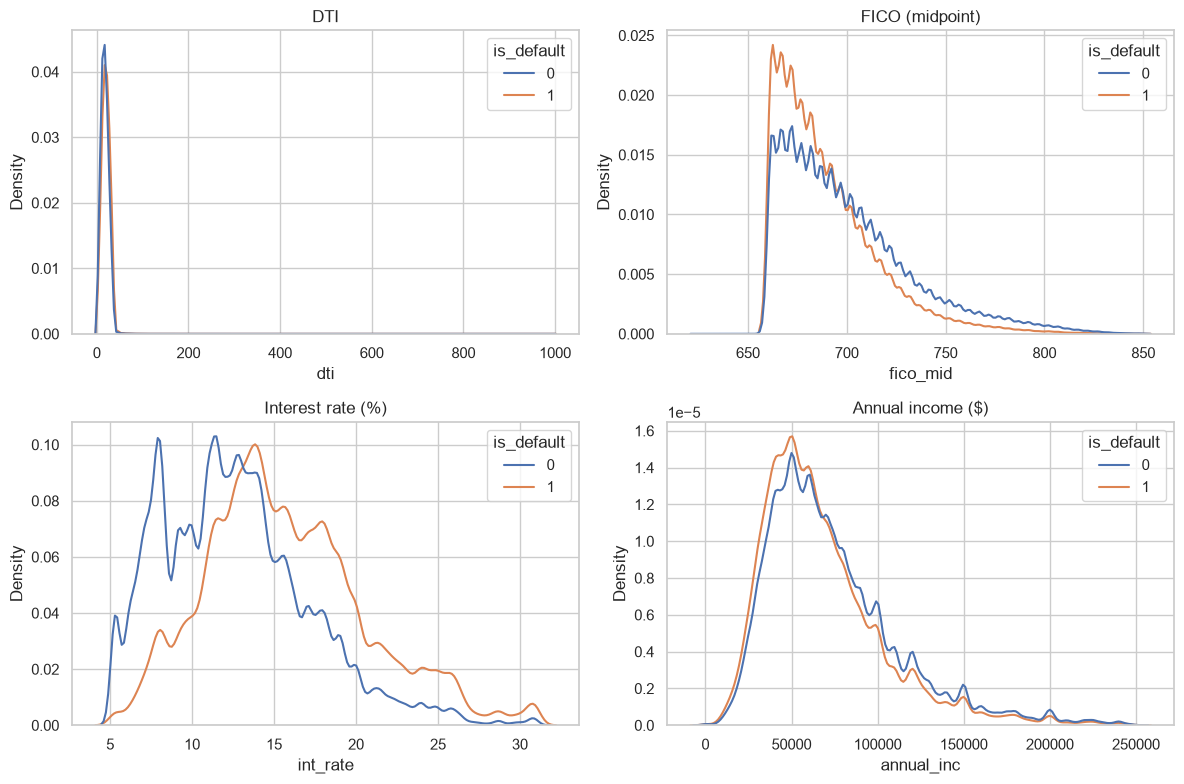

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

feature_axes = [
    ("dti", "DTI", axes[0, 0]),
    ("fico_mid", "FICO (midpoint)", axes[0, 1]),
    ("int_rate", "Interest rate (%)", axes[1, 0]),
    ("annual_inc", "Annual income ($)", axes[1, 1]),
]

for col, label, ax in feature_axes:
    data = resolved[[col, "is_default"]].dropna()
    if col == "annual_inc":
        data = data[data[col] < data[col].quantile(0.99)]
    sns.kdeplot(data=data, x=col, hue="is_default", common_norm=False, ax=ax)
    ax.set_title(label)

plt.tight_layout()
plt.show()

## 7. Interest rate vs. FICO

LendingClub prices risk into `int_rate`, so this should show a clear inverse relationship with FICO.

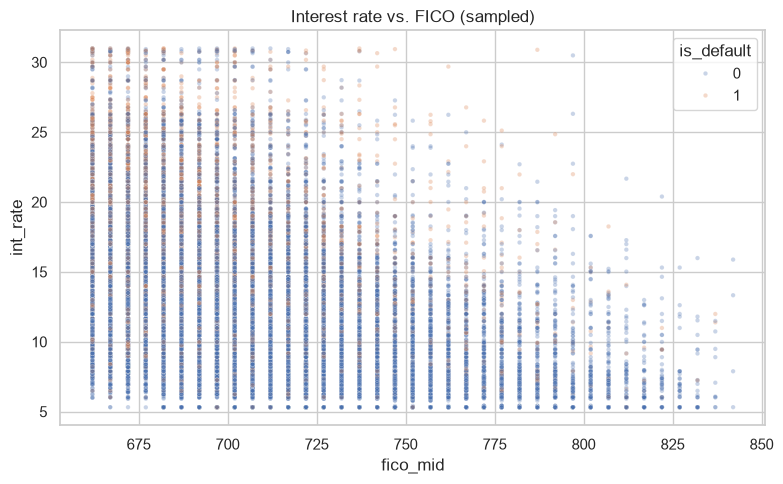

In [14]:
sample = resolved.sample(min(50_000, len(resolved)), random_state=0)

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=sample, x="fico_mid", y="int_rate", hue="is_default", alpha=0.3, s=10, ax=ax)
ax.set_title("Interest rate vs. FICO (sampled)")
plt.tight_layout()
plt.show()

## 8. Correlation of numeric risk drivers with default

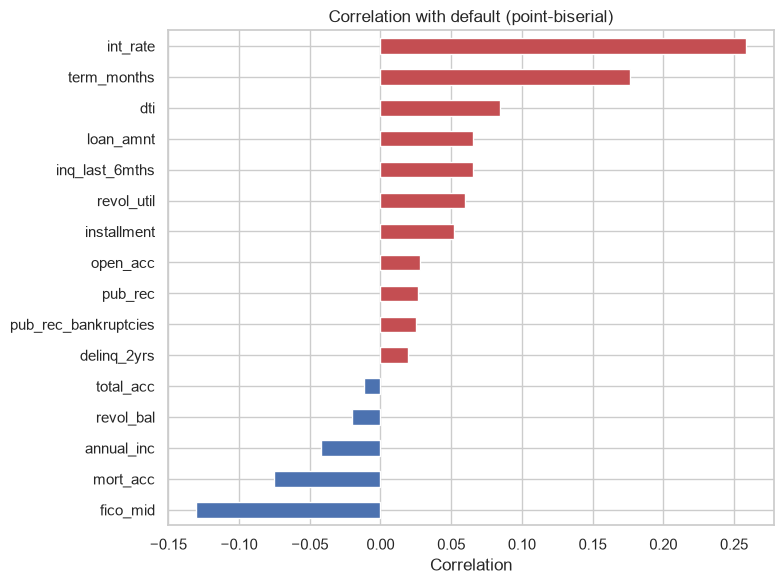

In [15]:
numeric_cols = [
    "loan_amnt", "int_rate", "installment", "annual_inc", "dti",
    "delinq_2yrs", "fico_mid", "inq_last_6mths", "open_acc", "pub_rec",
    "revol_bal", "revol_util", "total_acc", "mort_acc",
    "pub_rec_bankruptcies", "term_months", "is_default",
]

corr = resolved[numeric_cols].corr()["is_default"].drop("is_default").sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
corr.plot(kind="barh", color=["#C44E52" if v > 0 else "#4C72B0" for v in corr], ax=ax)
ax.set_title("Correlation with default (point-biserial)")
ax.set_xlabel("Correlation")
plt.tight_layout()
plt.show()

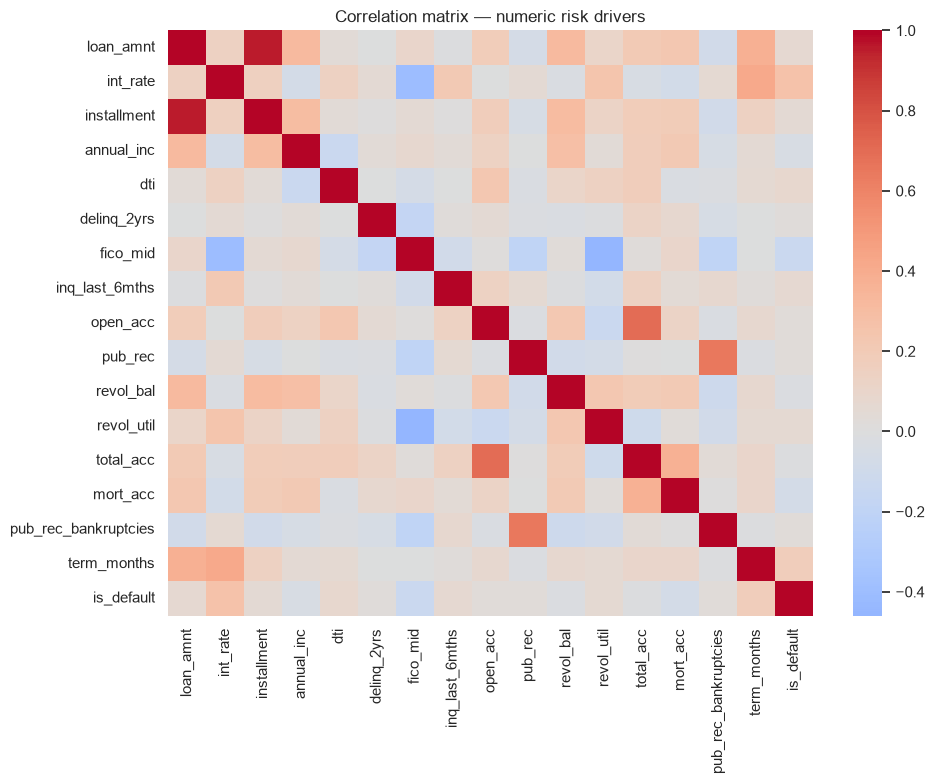

In [16]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(resolved[numeric_cols].corr(), cmap="coolwarm", center=0, annot=False, ax=ax)
ax.set_title("Correlation matrix — numeric risk drivers")
plt.tight_layout()
plt.show()

## 9. Summary

Fill in after reviewing the charts above — e.g.:

- Default rate rises monotonically from grade A to G, confirming LendingClub's grading is predictive.
- `int_rate`, `dti`, and `inq_last_6mths` are the numeric fields most positively correlated with default; `fico_mid` and `annual_inc` are negatively correlated.
- Certain purposes (e.g. small business) carry materially higher default rates than others (e.g. debt consolidation, credit card refinance).

These findings motivate the next step: translating risk drivers into approval-cutoff strategy (e.g. FICO/DTI thresholds, grade-based pricing) in a follow-up notebook.